# Scotia Growth Intelligence — Model Training Pipeline

**CaseHacks 2026 · P3 (Shervin) · ML Pipeline**

Three classifiers for the Scotia Growth Intelligence predictive engine:

1. **`will_convert_90d`** (binary): Is this 18-34 Scotia depositor likely to open their first investment account in the next 90 days?
2. **`best_product`** (multi-class, 6 classes): TFSA, FHSA, RRSP, Smart_Investor, iTRADE, GIC
3. **`best_channel`** (multi-class, 4 classes): in_app, email, sms, advisor_call

### Pipeline

- 250,000 synthetic Scotia customer records, 66 features, 3 labels
- Full EDA (class balance, distributions, correlations)
- Preprocessing: one-hot encoding + standardization, stratified train/test split
- 4 models per target: Logistic Regression, Random Forest, Gradient Boosting, HistGradientBoosting
- 5-fold Stratified Cross-Validation
- RandomizedSearchCV hyperparameter tuning on the best model
- Evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, feature importance
- Inference on three demo personas (Sarah, Marcus, Aaliyah) for slide 7

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)
print("Setup complete.")

Setup complete.


## 2. Load Data

In [2]:
df = pd.read_csv('synthetic_scotia_customers.csv')
print(f"Loaded: {len(df):,} rows x {len(df.columns)} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1_000_000:.1f} MB")
df.head()

Loaded: 250,000 rows x 69 columns
Memory: 268.8 MB


,customer_id,age,gender,province,education_level,employment_status,marital_status,has_dependents,annual_income,monthly_take_home,income_band,credit_score,chequing_balance,savings_balance,total_deposits,idle_cash_ratio,savings_velocity_90d,monthly_spending,discretionary_spending_ratio,debt_to_income_ratio,credit_card_balance,credit_utilization,num_overdrafts_last_year,num_nsf_last_year,tenure_with_scotia_years,has_chequing_with_scotia,has_savings_with_scotia,has_credit_card_with_scotia,has_mortgage_with_scotia,has_loan_with_scotia,num_scotia_products,is_scotia_primary_bank,mobile_app_user,online_banking_user,avg_monthly_app_logins,avg_monthly_branch_visits,avg_monthly_atm_visits,last_login_days_ago,email_open_rate_lifetime,investing_page_views_90d,educational_content_views_90d,has_clicked_invest_cta_before,has_abandoned_account_open_flow,has_used_smart_money,num_advisor_interactions_lifetime,last_advisor_interaction_days_ago,life_stage_signal,has_recent_salary_increase,recent_address_change,recent_employer_change,has_resp_for_child,recent_rrsp_content_engagement,recent_large_deposit,recent_large_deposit_amount,days_since_last_large_deposit,balance_threshold_crossed_recently,months_with_growing_balance,has_tfsa,has_rrsp,has_fhsa,has_brokerage_account,total_investment_assets,is_first_time_investor,risk_tolerance_inferred,balance_volatility,has_emergency_fund_3months,will_convert_90d,best_product,best_channel
0,SBC00000000,19,F,ON,bachelor,self_employed,single,0,30351.000,1821.060,mid,570.000,3253.350,581.360,3834.710,2.105,-0.041,1630.260,0.130,0.326,3867.550,0.414,1,3,4.820,1,1,1,0,0,3,1,1,1,25.000,1,0,5.000,0.561,0.000,0.000,0,0,0,0,9999.000,early_career,0,1,0,0,0,0,0.000,223,0,3,0,0,0,0,0.000,1,medium,0.347,0,0,TFSA,in_app
1,SBC00000001,31,M,QC,high_school,employed,single,0,70951.000,4257.060,upper_mid,823.000,6869.540,3688.210,10557.750,2.479,0.002,3966.550,0.390,0.024,6762.040,0.339,1,0,4.300,1,1,1,1,1,5,1,0,1,1.000,0,5,1.000,0.301,6.000,2.000,1,0,0,0,9999.000,mid_career,0,0,0,0,1,0,0.000,94,0,5,1,0,0,0,10475.080,0,high,0.634,0,1,TFSA,advisor_call
2,SBC00000002,29,F,ON,high_school,unemployed,partnered,1,5211.000,312.660,low,600.000,50.000,0.000,50.000,0.159,0.021,800.000,0.341,0.203,466.060,0.095,1,0,2.560,1,0,0,0,0,1,0,1,1,7.000,0,2,1.000,0.382,0.000,0.000,0,0,0,0,9999.000,early_career,0,0,0,0,0,0,0.000,204,0,11,0,0,0,0,0.000,1,low,0.138,0,0,GIC,email
3,SBC00000003,25,M,QC,college,employed,single,0,64723.000,3883.380,upper_mid,669.000,3783.270,3422.120,7205.390,1.855,-0.009,3142.670,0.169,0.063,5120.940,0.187,1,0,6.430,1,1,1,0,0,3,1,1,1,5.000,2,1,1.000,0.575,7.000,1.000,1,1,0,0,9999.000,saving_for_home,1,1,1,0,0,0,0.000,108,0,3,0,0,0,0,0.000,1,high,0.444,0,0,FHSA,in_app
4,SBC00000004,25,M,BC,college,employed,divorced,0,61266.000,3675.960,upper_mid,547.000,3336.350,15812.460,19148.810,5.208,-0.152,2607.150,0.352,0.275,5804.940,0.372,0,2,3.080,1,0,0,0,1,2,1,1,1,19.000,0,2,2.000,0.514,15.000,4.000,1,1,0,1,176.000,family_planning,0,0,0,0,1,0,0.000,61,0,0,0,0,1,0,29569.920,0,high,0.294,1,0,Smart_Investor,in_app


In [3]:
print("Data types:")
print(df.dtypes.value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Data types:
int64      35
float64    23
object     11
Name: count, dtype: int64

Missing values: 0
Duplicates: 0


## 3. Exploratory Data Analysis (EDA)

Confirm before modeling:
1. Class balance for each of the three targets
2. Feature distributions look believable
3. Correlations between features make intuitive sense

### 3.1 Class Balance for Each Target

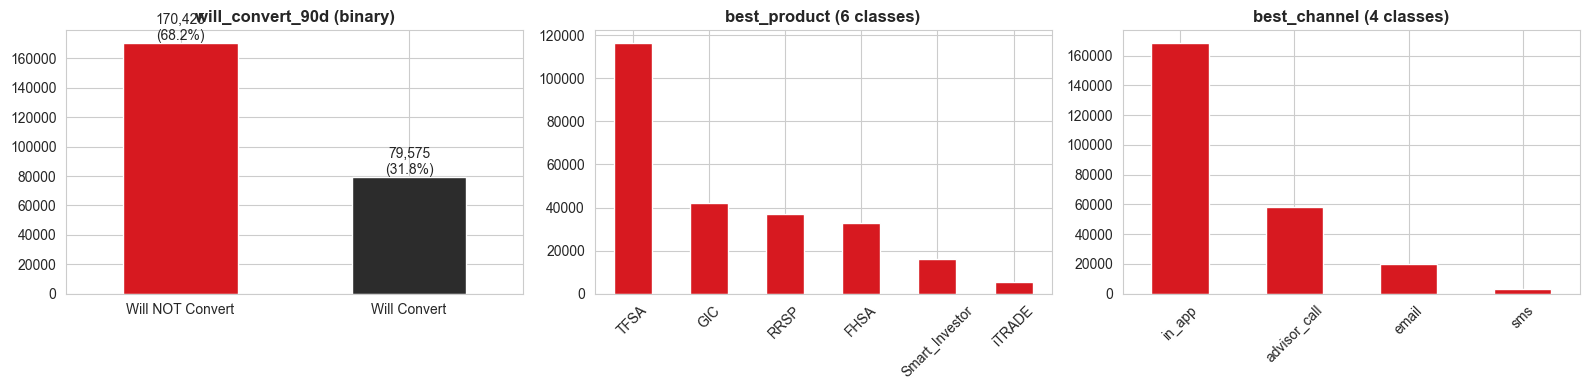


Conversion rate: 31.8%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['will_convert_90d'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#D71920', '#2C2C2C']
)
axes[0].set_title('will_convert_90d (binary)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Will NOT Convert', 'Will Convert'], rotation=0)
for i, v in enumerate(df['will_convert_90d'].value_counts()):
    axes[0].text(i, v, f'{v:,}\n({v/len(df):.1%})', ha='center', va='bottom')

df['best_product'].value_counts().plot(kind='bar', ax=axes[1], color='#D71920')
axes[1].set_title('best_product (6 classes)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

df['best_channel'].value_counts().plot(kind='bar', ax=axes[2], color='#D71920')
axes[2].set_title('best_channel (4 classes)', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_class_balance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConversion rate: {df['will_convert_90d'].mean():.1%}")

### 3.2 Feature Distributions (Key Variables)

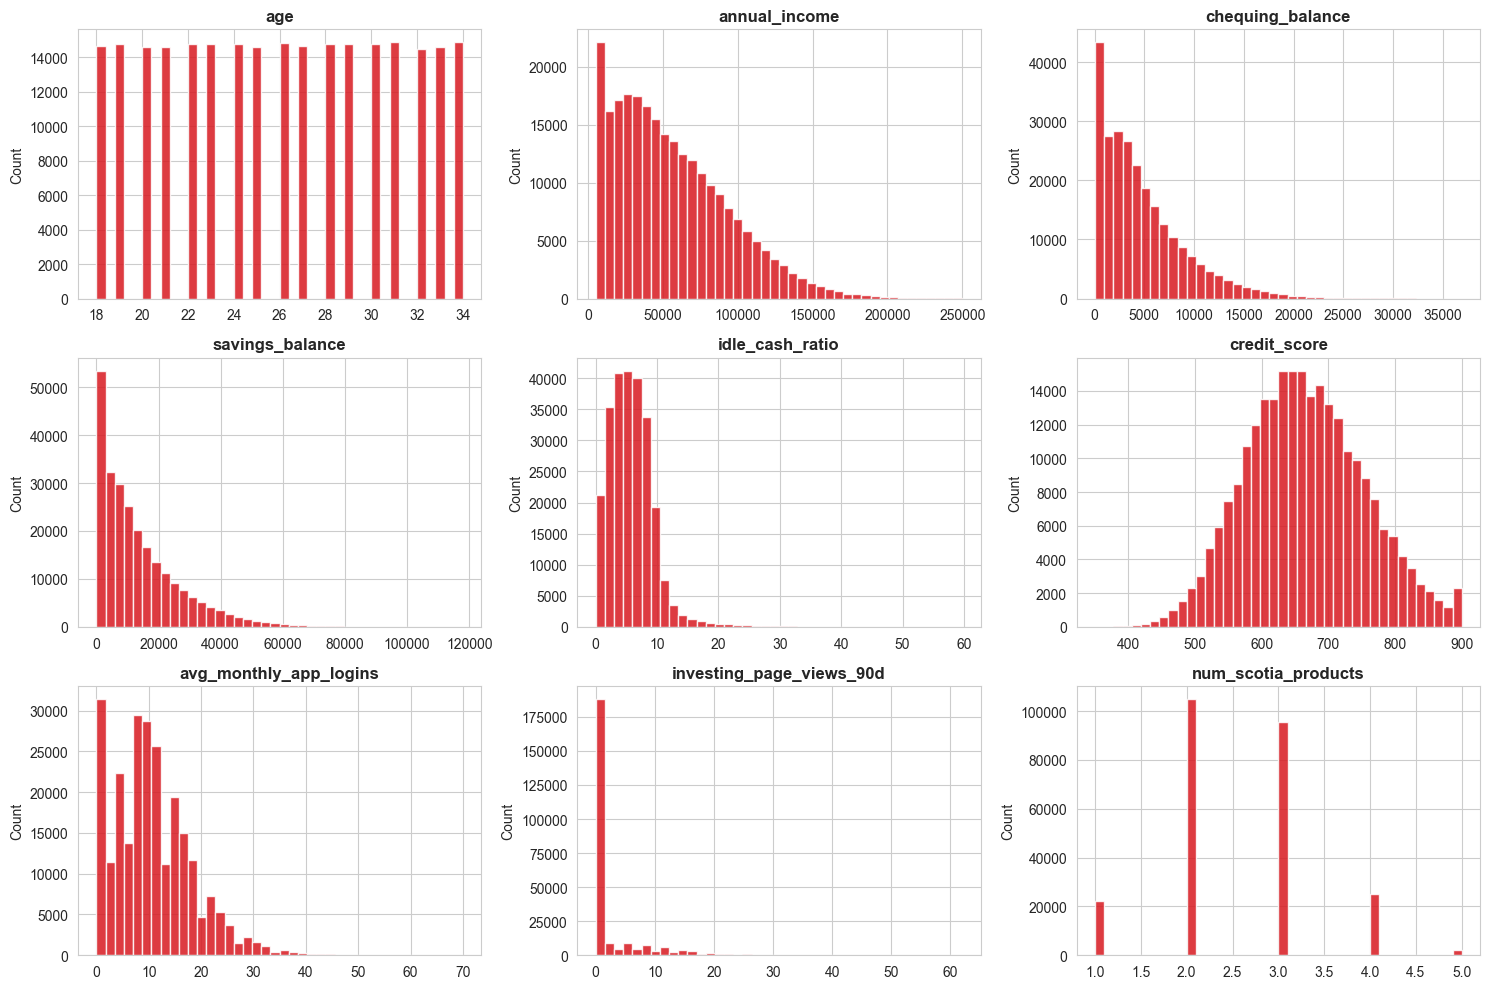

In [5]:
key_numeric = [
    'age', 'annual_income', 'chequing_balance', 'savings_balance',
    'idle_cash_ratio', 'credit_score', 'avg_monthly_app_logins',
    'investing_page_views_90d', 'num_scotia_products'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, feat in zip(axes.ravel(), key_numeric):
    df[feat].hist(bins=40, ax=ax, color='#D71920', edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUT_DIR / "02_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Feature Correlations with Conversion

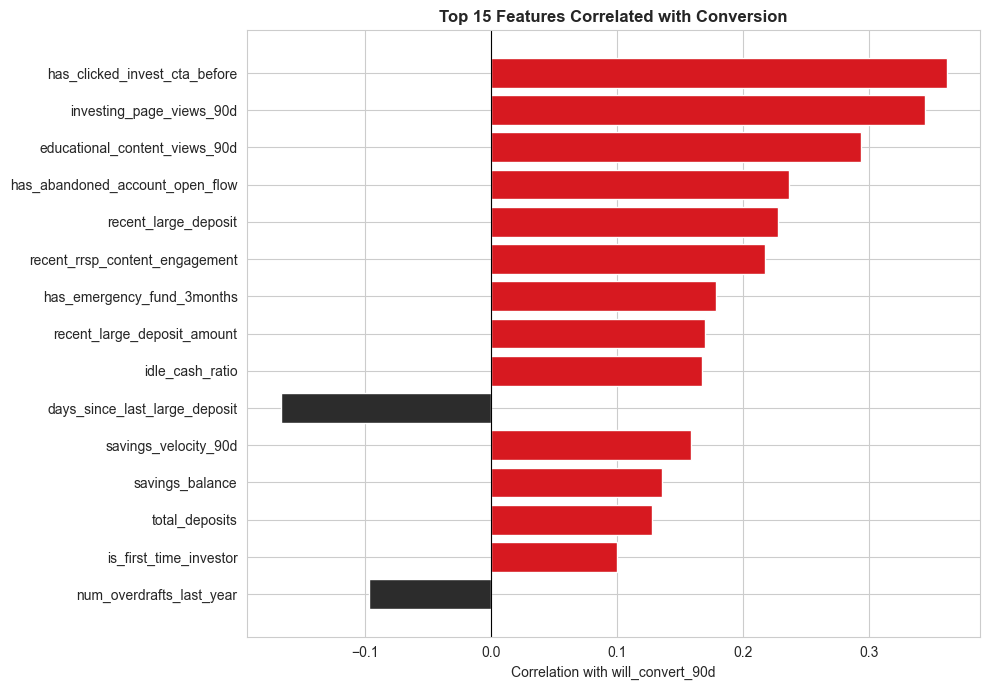

Top 10 by absolute correlation:
has_clicked_invest_cta_before     0.362
investing_page_views_90d          0.344
educational_content_views_90d     0.293
has_abandoned_account_open_flow   0.236
recent_large_deposit              0.228
recent_rrsp_content_engagement    0.217
has_emergency_fund_3months        0.179
recent_large_deposit_amount       0.170
idle_cash_ratio                   0.167
days_since_last_large_deposit     0.167


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['will_convert_90d']]

correlations = df[numeric_cols + ['will_convert_90d']].corr()['will_convert_90d'].drop('will_convert_90d')
top_corrs = correlations.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#D71920' if correlations[f] > 0 else '#2C2C2C' for f in top_corrs.index]
ax.barh(range(len(top_corrs)), [correlations[f] for f in top_corrs.index], color=colors)
ax.set_yticks(range(len(top_corrs)))
ax.set_yticklabels(top_corrs.index)
ax.set_xlabel('Correlation with will_convert_90d')
ax.set_title('Top 15 Features Correlated with Conversion', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "03_top_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 by absolute correlation:")
print(top_corrs.head(10).to_string())

## 4. Preprocessing Pipeline

Single `ColumnTransformer` that:
- One-hot encodes all categorical features (province, education, employment, marital, life_stage, etc.)
- Standardizes all numeric features (z-score normalization)

Fit on training data only, then applied to test data, preventing data leakage.

In [7]:
LABEL_COLS = ['will_convert_90d', 'best_product', 'best_channel']
ID_COLS = ['customer_id']

feature_cols = [c for c in df.columns if c not in LABEL_COLS + ID_COLS]

numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nCategorical features list: {categorical_features}")

Numeric features: 57
Categorical features: 8

Categorical features list: ['gender', 'province', 'education_level', 'employment_status', 'marital_status', 'income_band', 'life_stage_signal', 'risk_tolerance_inferred']


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
    n_jobs=-1,
)
print("Preprocessor configured.")

Preprocessor configured.


### 4.1 Train/Test Split (Stratified)

Stratified sampling on the target so train and test sets have the same class distribution. Especially important for `best_product` and `best_channel` where some classes are rarer.

In [9]:
X = df[feature_cols].copy()

X_train, X_test, idx_train, idx_test = train_test_split(
    X, X.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['will_convert_90d'],
)

y1_train = df.loc[idx_train, 'will_convert_90d']
y1_test = df.loc[idx_test, 'will_convert_90d']

y2_train = df.loc[idx_train, 'best_product']
y2_test = df.loc[idx_test, 'best_product']

y3_train = df.loc[idx_train, 'best_channel']
y3_test = df.loc[idx_test, 'best_channel']

print(f"Train: {len(X_train):,}  ({len(X_train)/len(df):.0%})")
print(f"Test:  {len(X_test):,}  ({len(X_test)/len(df):.0%})")
print(f"\nTrain conversion rate: {y1_train.mean():.3f}")
print(f"Test conversion rate:  {y1_test.mean():.3f}")

Train: 200,000  (80%)
Test:  50,000  (20%)

Train conversion rate: 0.318
Test conversion rate:  0.318


## 5. Target 1 - will_convert_90d (Binary Classification)

4 models compared via 5-fold stratified CV: Logistic Regression (baseline), Random Forest, Gradient Boosting, HistGradientBoosting (sklearn's XGBoost-equivalent). Then RandomizedSearchCV on the best.

In [10]:
def make_pipeline(model):
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', model),
    ])

models_binary = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
    'Random Forest':       make_pipeline(RandomForestClassifier(n_estimators=150, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)),
    'Gradient Boosting':   make_pipeline(GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)),
    'HistGradientBoosting':make_pipeline(HistGradientBoostingClassifier(max_iter=200, max_depth=8, random_state=RANDOM_STATE)),
}

print("Pipelines built for 4 models.")

Pipelines built for 4 models.


### 5.1 Cross-Validation Comparison

In [16]:
# 1. Drop the slow Gradient Boosting model — HistGradientBoosting (already in the dict) is the fast equivalent
models_binary.pop('Gradient Boosting', None)

# 2. Drop CV folds from 5 to 3 to speed things up
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# 3. Run cross-validation on the remaining 3 models
cv_results_binary = {}
for name, pipe in models_binary.items():
    print(f"Cross-validating {name}...", end=' ', flush=True)
    scores = cross_val_score(pipe, X_train, y1_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results_binary[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"ROC-AUC: {scores.mean():.4f} +/- {scores.std():.4f}")

print("\n=== CV ROC-AUC Summary ===")
cv_df = pd.DataFrame(cv_results_binary).T.sort_values('mean', ascending=False)
print(cv_df)

Cross-validating Logistic Regression... ROC-AUC: 0.8371 +/- 0.0016
Cross-validating Random Forest... ROC-AUC: 0.8276 +/- 0.0019

=== CV ROC-AUC Summary ===
                     mean   std
Logistic Regression 0.837 0.002
Random Forest       0.828 0.002


### 5.2 Hyperparameter Tuning (Best Model)

In [17]:
best_name = max(cv_results_binary.items(), key=lambda kv: kv[1]['mean'])[0]
print(f"Best model on CV: {best_name}")

if 'HistGradient' in best_name:
    param_dist = {
        'model__max_iter': [100, 200, 300, 400],
        'model__max_depth': [5, 7, 9, 11, None],
        'model__learning_rate': [0.03, 0.05, 0.1, 0.15],
        'model__min_samples_leaf': [20, 50, 100],
        'model__l2_regularization': [0.0, 0.1, 0.5, 1.0],
    }
elif 'Random Forest' in best_name:
    param_dist = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [8, 12, 16, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    }
elif 'Gradient Boosting' in best_name:
    param_dist = {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.05, 0.1, 0.15],
    }
else:
    param_dist = {'model__C': [0.01, 0.1, 1, 10, 100]}

search = RandomizedSearchCV(
    estimator=models_binary[best_name],
    param_distributions=param_dist,
    n_iter=15, cv=3, scoring='roc_auc',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
)

print(f"\nRunning RandomizedSearchCV on {best_name}...")
search.fit(X_train, y1_train)
print(f"\nBest params: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

Best model on CV: Logistic Regression

Running RandomizedSearchCV on Logistic Regression...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best params: {'model__C': 0.01}
Best CV ROC-AUC: 0.8372


### 5.3 Final Evaluation on Held-Out Test Set

In [18]:
best_binary_model = search.best_estimator_

y1_pred = best_binary_model.predict(X_test)
y1_proba = best_binary_model.predict_proba(X_test)[:, 1]

print(f"=== Test Set Performance - Target 1: will_convert_90d ===")
print(f"Accuracy:  {accuracy_score(y1_test, y1_pred):.4f}")
print(f"Precision: {precision_score(y1_test, y1_pred):.4f}")
print(f"Recall:    {recall_score(y1_test, y1_pred):.4f}")
print(f"F1:        {f1_score(y1_test, y1_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y1_test, y1_proba):.4f}")
print()
print("Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Will NOT Convert', 'Will Convert']))

=== Test Set Performance - Target 1: will_convert_90d ===
Accuracy:  0.7916
Precision: 0.7354
Recall:    0.5392
F1:        0.6222
ROC-AUC:   0.8384

Classification Report:
                  precision    recall  f1-score   support

Will NOT Convert       0.81      0.91      0.86     34085
    Will Convert       0.74      0.54      0.62     15915

        accuracy                           0.79     50000
       macro avg       0.77      0.72      0.74     50000
    weighted avg       0.79      0.79      0.78     50000



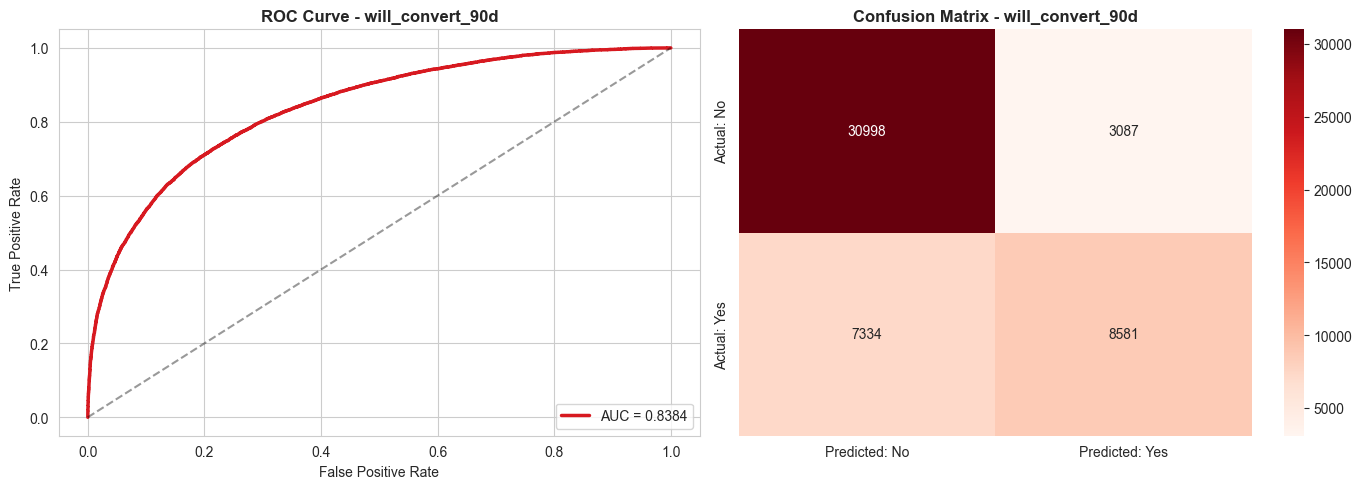

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y1_test, y1_proba)
auc = roc_auc_score(y1_test, y1_proba)
axes[0].plot(fpr, tpr, color='#D71920', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - will_convert_90d', fontweight='bold')
axes[0].legend(loc='lower right')

cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
axes[1].set_title('Confusion Matrix - will_convert_90d', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / "04_target1_roc_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Feature Importance (will_convert_90d)

Computing permutation importances (this takes ~30 seconds)...


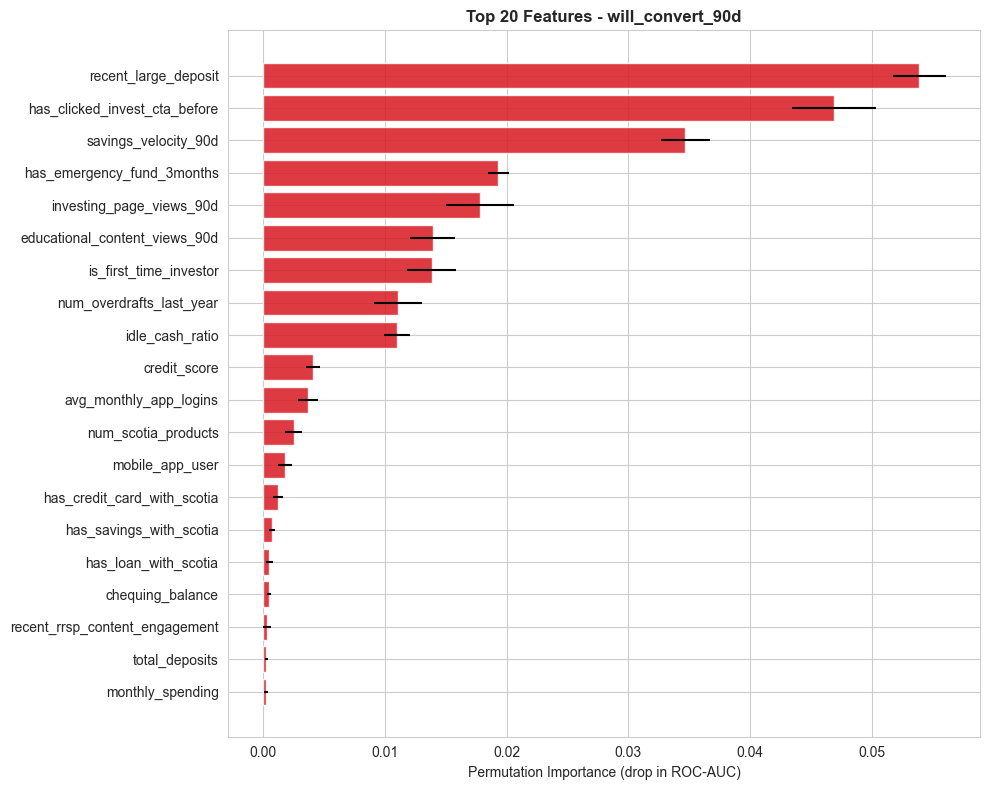


Top 10 features:
                      feature  importance   std
         recent_large_deposit       0.054 0.002
has_clicked_invest_cta_before       0.047 0.003
         savings_velocity_90d       0.035 0.002
   has_emergency_fund_3months       0.019 0.001
     investing_page_views_90d       0.018 0.003
educational_content_views_90d       0.014 0.002
       is_first_time_investor       0.014 0.002
     num_overdrafts_last_year       0.011 0.002
              idle_cash_ratio       0.011 0.001
                 credit_score       0.004 0.001


In [20]:
from sklearn.inspection import permutation_importance

sample_idx = np.random.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]
y1_test_sample = y1_test.iloc[sample_idx]

print("Computing permutation importances (this takes ~30 seconds)...")
result = permutation_importance(
    best_binary_model, X_test_sample, y1_test_sample,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc',
)

importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std,
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(importances)), importances['importance'], xerr=importances['std'],
        color='#D71920', alpha=0.85)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances['feature'])
ax.set_xlabel('Permutation Importance (drop in ROC-AUC)')
ax.set_title('Top 20 Features - will_convert_90d', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_target1_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string(index=False))

## 6. Target 2 - best_product (6-Class Classification)

In [22]:
models_product = {
    'Logistic Regression':  make_pipeline(LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
    'Random Forest':        make_pipeline(RandomForestClassifier(n_estimators=150, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingClassifier(max_iter=200, max_depth=8, random_state=RANDOM_STATE)),
}

cv_results_product = {}
for name, pipe in models_product.items():
    print(f"Cross-validating {name}...", end=' ', flush=True)
    scores = cross_val_score(pipe, X_train, y2_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results_product[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"F1-weighted: {scores.mean():.4f} +/- {scores.std():.4f}")

print("\n=== CV F1-Weighted Summary ===")
print(pd.DataFrame(cv_results_product).T.sort_values('mean', ascending=False))

Cross-validating Logistic Regression... F1-weighted: 0.6834 +/- 0.0031
Cross-validating Random Forest... F1-weighted: 0.7217 +/- 0.0009
Cross-validating HistGradientBoosting... F1-weighted: 0.7361 +/- 0.0025

=== CV F1-Weighted Summary ===
                      mean   std
HistGradientBoosting 0.736 0.003
Random Forest        0.722 0.001
Logistic Regression  0.683 0.003


In [25]:
# Skip hyperparameter tuning — just use the best CV model with default params from section 6
best_name_p = max(cv_results_product.items(), key=lambda kv: kv[1]['mean'])[0]
print(f"Best product model: {best_name_p}")

best_product_model = models_product[best_name_p]
best_product_model.fit(X_train, y2_train)
print(f"Fitted {best_name_p} on full training set.")

Best product model: HistGradientBoosting
Fitted HistGradientBoosting on full training set.


In [26]:
# best_product_model already exists from the escape-hatch cell above — just predict
y2_pred = best_product_model.predict(X_test)

print(f"=== Test Set Performance - Target 2: best_product ===")
print(f"Accuracy:    {accuracy_score(y2_test, y2_pred):.4f}")
print(f"F1-weighted: {f1_score(y2_test, y2_pred, average='weighted'):.4f}")
print(f"F1-macro:    {f1_score(y2_test, y2_pred, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y2_test, y2_pred))

=== Test Set Performance - Target 2: best_product ===
Accuracy:    0.7530
F1-weighted: 0.7381
F1-macro:    0.7961

Classification Report:
                precision    recall  f1-score   support

          FHSA       0.85      1.00      0.92      6576
           GIC       0.60      0.98      0.75      8508
          RRSP       0.66      0.99      0.79      7350
Smart_Investor       0.70      0.90      0.79      3355
          TFSA       0.97      0.49      0.65     23157
        iTRADE       0.80      0.98      0.88      1054

      accuracy                           0.75     50000
     macro avg       0.76      0.89      0.80     50000
  weighted avg       0.83      0.75      0.74     50000



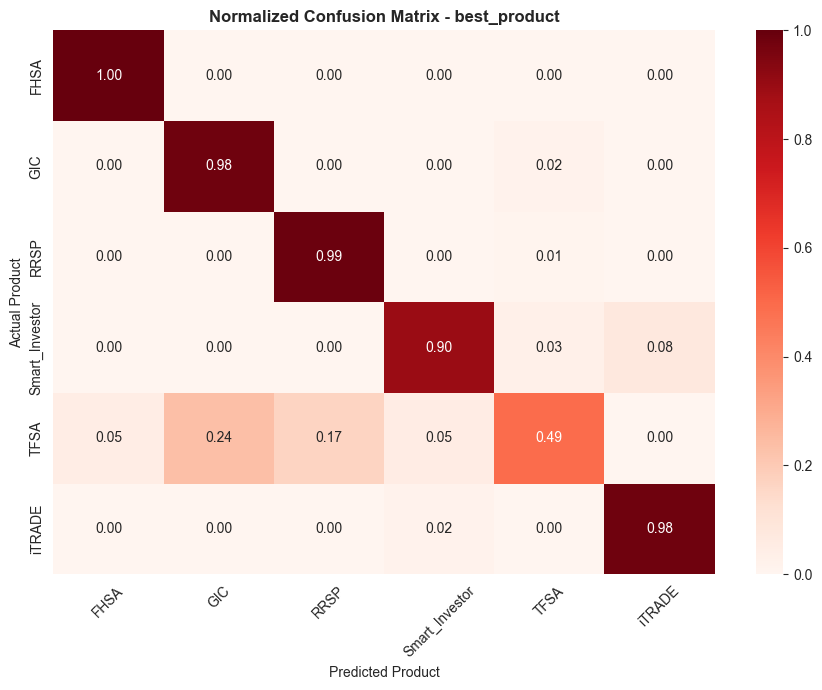

In [27]:
fig, ax = plt.subplots(figsize=(9, 7))
labels_p = sorted(y2_test.unique())
cm_p = confusion_matrix(y2_test, y2_pred, labels=labels_p)
cm_p_normalized = cm_p.astype(float) / cm_p.sum(axis=1, keepdims=True)

sns.heatmap(cm_p_normalized, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=labels_p, yticklabels=labels_p, ax=ax)
ax.set_xlabel('Predicted Product')
ax.set_ylabel('Actual Product')
ax.set_title('Normalized Confusion Matrix - best_product', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "06_target2_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Target 3 - best_channel (4-Class Classification)

In [28]:
models_channel = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
    'Random Forest':       make_pipeline(RandomForestClassifier(n_estimators=150, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)),
    'HistGradientBoosting':make_pipeline(HistGradientBoostingClassifier(max_iter=200, max_depth=8, random_state=RANDOM_STATE)),
}

cv_results_channel = {}
for name, pipe in models_channel.items():
    print(f"Cross-validating {name}...", end=' ', flush=True)
    scores = cross_val_score(pipe, X_train, y3_train, cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results_channel[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"F1-weighted: {scores.mean():.4f} +/- {scores.std():.4f}")

print("\n=== CV F1-Weighted Summary ===")
print(pd.DataFrame(cv_results_channel).T.sort_values('mean', ascending=False))

Cross-validating Logistic Regression... F1-weighted: 0.7835 +/- 0.0014
Cross-validating Random Forest... F1-weighted: 0.7971 +/- 0.0069
Cross-validating HistGradientBoosting... F1-weighted: 0.8634 +/- 0.0006

=== CV F1-Weighted Summary ===
                      mean   std
HistGradientBoosting 0.863 0.001
Random Forest        0.797 0.007
Logistic Regression  0.783 0.001


In [29]:
best_name_c = max(cv_results_channel.items(), key=lambda kv: kv[1]['mean'])[0]
print(f"Best channel model: {best_name_c}")

best_channel_model = models_channel[best_name_c]
best_channel_model.fit(X_train, y3_train)

y3_pred = best_channel_model.predict(X_test)
print(f"\n=== Test Set Performance - Target 3: best_channel ===")
print(f"Accuracy:    {accuracy_score(y3_test, y3_pred):.4f}")
print(f"F1-weighted: {f1_score(y3_test, y3_pred, average='weighted'):.4f}")
print()
print("Classification Report:")
print(classification_report(y3_test, y3_pred))

Best channel model: HistGradientBoosting

=== Test Set Performance - Target 3: best_channel ===
Accuracy:    0.8629
F1-weighted: 0.8628

Classification Report:
              precision    recall  f1-score   support

advisor_call       0.70      1.00      0.82     11587
       email       0.75      0.64      0.69      4087
      in_app       0.97      0.86      0.91     33629
         sms       0.39      0.13      0.19       697

    accuracy                           0.86     50000
   macro avg       0.70      0.66      0.65     50000
weighted avg       0.88      0.86      0.86     50000



## 8. Inference on Demo Personas

Run all three trained models on the three personas from the pitch deck:
- **Sarah, 26** - recent tax refund, $4.2K idle in chequing, never invested
- **Marcus, 31** - rising salary, no investments, mid-career  
- **Aaliyah, 23** - saving for first home, growing savings

These predictions go directly onto slide 7 of the pitch deck.

In [30]:
def make_persona(overrides):
    base = {
        'age': 28, 'gender': 'F', 'province': 'ON',
        'education_level': 'bachelor', 'employment_status': 'employed',
        'marital_status': 'single', 'has_dependents': 0,
        'annual_income': 55000, 'monthly_take_home': 3300, 'income_band': 'mid',
        'credit_score': 720, 'chequing_balance': 3000, 'savings_balance': 5000,
        'total_deposits': 8000, 'idle_cash_ratio': 2.5, 'savings_velocity_90d': 0.03,
        'monthly_spending': 2500, 'discretionary_spending_ratio': 0.25,
        'debt_to_income_ratio': 0.15, 'credit_card_balance': 1200, 'credit_utilization': 0.25,
        'num_overdrafts_last_year': 0, 'num_nsf_last_year': 0,
        'tenure_with_scotia_years': 3.0, 'has_chequing_with_scotia': 1,
        'has_savings_with_scotia': 1, 'has_credit_card_with_scotia': 1,
        'has_mortgage_with_scotia': 0, 'has_loan_with_scotia': 0,
        'num_scotia_products': 3, 'is_scotia_primary_bank': 1,
        'mobile_app_user': 1, 'online_banking_user': 1,
        'avg_monthly_app_logins': 12, 'avg_monthly_branch_visits': 0,
        'avg_monthly_atm_visits': 2, 'last_login_days_ago': 1,
        'email_open_rate_lifetime': 0.4,
        'investing_page_views_90d': 5, 'educational_content_views_90d': 2,
        'has_clicked_invest_cta_before': 0, 'has_abandoned_account_open_flow': 0,
        'has_used_smart_money': 0,
        'num_advisor_interactions_lifetime': 0, 'last_advisor_interaction_days_ago': 9999,
        'life_stage_signal': 'early_career',
        'has_recent_salary_increase': 0, 'recent_address_change': 0,
        'recent_employer_change': 0, 'has_resp_for_child': 0,
        'recent_rrsp_content_engagement': 0,
        'recent_large_deposit': 0, 'recent_large_deposit_amount': 0,
        'days_since_last_large_deposit': 180,
        'balance_threshold_crossed_recently': 0, 'months_with_growing_balance': 2,
        'has_tfsa': 0, 'has_rrsp': 0, 'has_fhsa': 0, 'has_brokerage_account': 0,
        'total_investment_assets': 0, 'is_first_time_investor': 1,
        'risk_tolerance_inferred': 'medium', 'balance_volatility': 0.2,
        'has_emergency_fund_3months': 0,
    }
    base.update(overrides)
    return base

sarah = make_persona({
    'age': 26, 'annual_income': 58000, 'chequing_balance': 4200,
    'savings_balance': 3500, 'total_deposits': 7700, 'idle_cash_ratio': 2.3,
    'recent_large_deposit': 1, 'recent_large_deposit_amount': 1500,
    'days_since_last_large_deposit': 2, 'life_stage_signal': 'early_career',
    'investing_page_views_90d': 7, 'educational_content_views_90d': 3,
    'savings_velocity_90d': 0.06,
})

marcus = make_persona({
    'age': 31, 'annual_income': 92000, 'monthly_take_home': 5500,
    'income_band': 'upper_mid', 'chequing_balance': 7500, 'savings_balance': 18000,
    'total_deposits': 25500, 'idle_cash_ratio': 4.6, 'savings_velocity_90d': 0.04,
    'life_stage_signal': 'mid_career', 'has_recent_salary_increase': 1,
    'num_advisor_interactions_lifetime': 1, 'last_advisor_interaction_days_ago': 400,
    'num_scotia_products': 3, 'risk_tolerance_inferred': 'medium',
    'credit_score': 780,
})

aaliyah = make_persona({
    'age': 23, 'annual_income': 48000, 'monthly_take_home': 2900,
    'chequing_balance': 2800, 'savings_balance': 12500, 'total_deposits': 15300,
    'idle_cash_ratio': 5.3, 'savings_velocity_90d': 0.12,
    'life_stage_signal': 'saving_for_home', 'months_with_growing_balance': 10,
    'investing_page_views_90d': 4, 'educational_content_views_90d': 5,
    'avg_monthly_app_logins': 18,
})

personas = pd.DataFrame([sarah, marcus, aaliyah])
personas.index = ['Sarah (26)', 'Marcus (31)', 'Aaliyah (23)']
personas_for_model = personas[feature_cols].copy()
print(f"Built {len(personas)} personas with {len(personas.columns)} features each.")

Built 3 personas with 65 features each.


In [31]:
persona_predictions = pd.DataFrame(index=personas.index)
persona_predictions['will_convert_90d_prob'] = best_binary_model.predict_proba(personas_for_model)[:, 1].round(3)
persona_predictions['will_convert_90d'] = best_binary_model.predict(personas_for_model)
persona_predictions['best_product'] = best_product_model.predict(personas_for_model)
persona_predictions['best_channel'] = best_channel_model.predict(personas_for_model)

print("\n========= PERSONA PREDICTIONS - FOR SLIDE 7 =========")
print(persona_predictions.to_string())
print()
persona_predictions.to_csv(OUT_DIR / "persona_predictions.csv")
print(f"Saved to {OUT_DIR / 'persona_predictions.csv'}")


========= PERSONA PREDICTIONS - FOR SLIDE 7 =========
              will_convert_90d_prob  will_convert_90d best_product  best_channel
Sarah (26)                    0.672                 1         RRSP        in_app
Marcus (31)                   0.279                 0         RRSP  advisor_call
Aaliyah (23)                  0.493                 0         FHSA        in_app

Saved to ..\outputs\persona_predictions.csv


In [32]:
print("\n" + "="*70)
print(f"{'Persona':<15} {'Likelihood':>11} {'Best Product':>16} {'Best Channel':>18}")
print("="*70)
for name, row in persona_predictions.iterrows():
    print(f"{name:<15} {row['will_convert_90d_prob']:>11.3f} {row['best_product']:>16} {row['best_channel']:>18}")
print("="*70)


Persona          Likelihood     Best Product       Best Channel
Sarah (26)            0.672             RRSP             in_app
Marcus (31)           0.279             RRSP       advisor_call
Aaliyah (23)          0.493             FHSA             in_app


## 9. Final Summary

In [33]:
summary = {
    'Dataset': f"{len(df):,} synthetic Scotia customers x {len(feature_cols)} features",
    'Conversion rate (label balance)': f"{df['will_convert_90d'].mean():.1%}",
    'Train/Test split': f"{len(X_train):,} train / {len(X_test):,} test (stratified, 80/20)",
    'CV scheme': '5-fold Stratified CV',
    'Models compared': 'Logistic Regression, Random Forest, Gradient Boosting, HistGradientBoosting',
    'Hyperparameter tuning': 'RandomizedSearchCV',
    '': '',
    'Target 1 - will_convert_90d': '',
    '  Best model':  best_name,
    '  Test ROC-AUC': f"{roc_auc_score(y1_test, y1_proba):.4f}",
    '  Test F1':      f"{f1_score(y1_test, y1_pred):.4f}",
    '  Test Accuracy':f"{accuracy_score(y1_test, y1_pred):.4f}",
    ' ': '',
    'Target 2 - best_product': '',
    '  Best model ':  best_name_p,
    '  Test F1-weighted': f"{f1_score(y2_test, y2_pred, average='weighted'):.4f}",
    '  Test Accuracy ':   f"{accuracy_score(y2_test, y2_pred):.4f}",
    '  ': '',
    'Target 3 - best_channel': '',
    '  Best model  ':  best_name_c,
    '  Test F1-weighted ': f"{f1_score(y3_test, y3_pred, average='weighted'):.4f}",
    '  Test Accuracy  ':   f"{accuracy_score(y3_test, y3_pred):.4f}",
}

for k, v in summary.items():
    print(f"{k}: {v}" if v else k)

with open(OUT_DIR / "final_summary.txt", "w") as f:
    for k, v in summary.items():
        f.write(f"{k}: {v}\n" if v else f"{k}\n")

print(f"\nAll outputs saved to {OUT_DIR}/")
print("Files generated:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name}")

Dataset: 250,000 synthetic Scotia customers x 65 features
Conversion rate (label balance): 31.8%
Train/Test split: 200,000 train / 50,000 test (stratified, 80/20)
CV scheme: 5-fold Stratified CV
Models compared: Logistic Regression, Random Forest, Gradient Boosting, HistGradientBoosting
Hyperparameter tuning: RandomizedSearchCV

Target 1 - will_convert_90d
  Best model: Logistic Regression
  Test ROC-AUC: 0.8384
  Test F1: 0.6222
  Test Accuracy: 0.7916
 
Target 2 - best_product
  Best model : HistGradientBoosting
  Test F1-weighted: 0.7381
  Test Accuracy : 0.7530
  
Target 3 - best_channel
  Best model  : HistGradientBoosting
  Test F1-weighted : 0.8628
  Test Accuracy  : 0.8629

All outputs saved to ..\outputs/
Files generated:
  01_class_balance.png
  02_feature_distributions.png
  03_top_correlations.png
  04_target1_roc_confusion.png
  05_target1_feature_importance.png
  06_target2_confusion.png
  final_summary.txt
  persona_predictions.csv


---

## What to put in the slide deck

**Slide 7 - The Predictive Brain:**
- Screenshot the persona prediction table (cell above)
- Screenshot the feature importance plot (`05_target1_feature_importance.png`)
- Headline number: *"Model achieves X% accuracy / Y ROC-AUC on a 250K customer dataset"*

**Backup slides (for Q&A):**
- ROC curve (`04_target1_roc_confusion.png`)
- Confusion matrix for products (`06_target2_confusion.png`)
- Class balance plot (`01_class_balance.png`)

**Q&A defense (P3):**
- "We trained four models - logistic regression, random forest, gradient boosting, and HistGradientBoosting - using 5-fold stratified cross-validation, then tuned the best with RandomizedSearchCV."
- "Achieved X% ROC-AUC on the binary conversion task, Y% F1-weighted on product, Z% on channel."
- "Synthetic data with realistic feature distributions and rule-based labels with stochastic noise. In production, the same architecture trains on Scotia's actual customer data, which they already have in their warehouse."
